#**Day 37 - Exploring Clustering Techniques with Python**
Student: **Daud Rusyad Nurdin**, *bootcamp DA/DS 34*

## Task
Simulasi sebagai Data Scientist di sebuah perusahaan penerbangan.
* Lakukan Segmentasi menggunakan K-mean Clustering
* Tuliskan insightnya (clustering analysis dan viz clustering) didalam python notebook/pdf/google slide.--> Insightnya berupa: (1) label dan (2) rekomendasi/treatment per cluster

Catatan:
* Tambahan bonus RFM analysis


##Import Library

In [ ]:
import pandas as pd
import numpy as np
import datetime

# Add the other libs
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Markdown, display

##Load dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True) # add command: ", force_remount=True" to avoid warning

# here is my data stored...
data_path = '/content/drive/My Drive/Dibimbing/Day 37 - Exploring Clustering Techniques with Python/'

Mounted at /content/drive/


**Data structure**

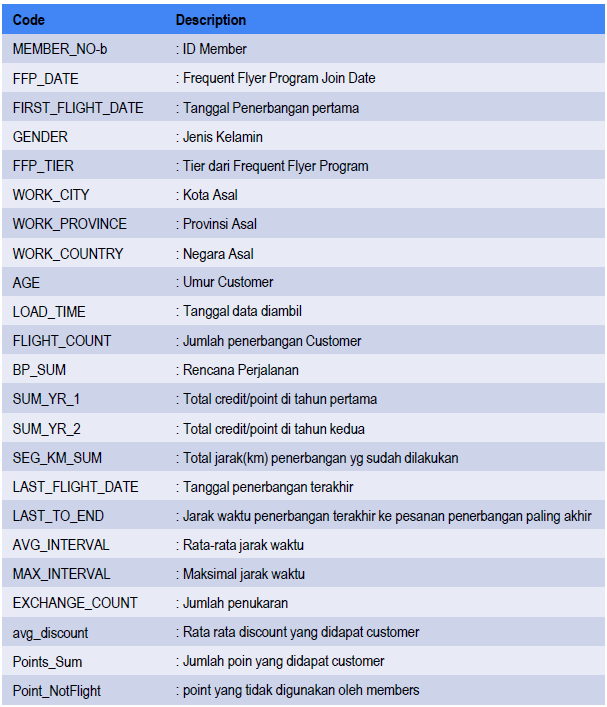

In [ ]:
df_ori = pd.read_csv(data_path + 'Salinan flight.csv')
df = df_ori.copy()
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

##Data Analysis & Cleaning

###Check uniqueness of MEMBER_NO

In [ ]:
# Memeriksa apakah nilai kolom MEMBER_NO unik?
total_rows = len(df)
unique_values = df['MEMBER_NO'].nunique()

if total_rows == unique_values:
    print("Semua nilai unik")
else:
    print("Ada nilai duplikat")

Semua nilai unik


Catatan:
* **Tidak ada kasus data duplicate**. Adapun MEMBER_NO tidak akan dibawa pada proses learning K-Means model, karena bukan data transaksi, hanya merupakan ID (key) dari data. Tetapi nanti akan digunakan sebagai index di dataframe.
* Jika diperhatikan ini merupakan data summary dari transaksi para pelanggan dari Frequent Flyer Program.

###Check min max FFP_TIER

In [ ]:
# Check min max FFP_TIER
display(Markdown(f"**Check FFP_TIER**"))
print(df['FFP_TIER'].value_counts())

**Check FFP_TIER**

FFP_TIER
4    58066
5     3409
6     1513
Name: count, dtype: int64


Catatan:
* Sebenarnya data ini adalah categorical, tetapi disini didefinisikan sebagai bertipe data Integer.

###Check value of WORK_CITY, WORK_PROVINCE & WORK_COUNTRY

In [ ]:
df[df['WORK_CITY'].str.len() <= 2]

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
20,21501,7/30/2008,11/21/2008,Male,6,.,beijing,CN,49.0,3/31/2014,...,122763.0,167113,3/28/2014,4,6.438095,31,4,1.369404,251134,9
27,47114,1/15/2005,3/17/2005,Male,6,.,beijing,CN,47.0,3/31/2014,...,83139.0,148685,3/21/2014,11,9.493151,51,8,1.433364,235176,14
40,18793,4/25/2006,6/2/2006,Male,6,.,beijing,CN,48.0,3/31/2014,...,85119.0,137876,3/30/2014,2,7.505155,46,11,1.458541,210435,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62610,16549,3/28/2013,4/26/2013,Male,4,-,-,CN,40.0,3/31/2014,...,692.0,1620,4/26/2013,341,0.000000,0,0,0.400000,605,0
62682,24276,3/29/2012,5/1/2012,Male,4,-,-,CN,24.0,3/31/2014,...,0.0,1522,5/7/2012,695,6.000000,6,0,0.400000,540,0
62683,32905,4/3/2012,4/28/2012,Female,4,-,-,CN,72.0,3/31/2014,...,0.0,1522,5/10/2012,692,12.000000,12,0,0.400000,540,0
62695,7352,3/21/2013,3/24/2013,Male,4,-,-,CN,57.0,3/31/2014,...,380.0,1506,4/23/2013,344,30.000000,30,0,0.400000,268,0


In [ ]:
df[df['WORK_PROVINCE'].str.len() <= 2]

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
11,37994,11/13/2004,12/2/2004,Male,6,beijing,.,CN,47.0,3/31/2014,...,126821.0,271438,3/26/2014,6,5.027778,42,15,0.952535,353101,66
12,28012,11/23/2006,11/18/2007,Male,5,SAN MARINO,CA,US,58.0,3/31/2014,...,53977.0,321529,1/25/2014,67,23.000000,112,3,0.799127,245808,4
23,28474,4/13/2010,4/13/2010,Male,6,NaN,CA,US,41.0,3/31/2014,...,59600.0,222380,1/18/2014,74,32.789474,110,8,1.004904,280760,9
59,11034,1/26/2005,3/9/2005,Male,5,beijing,.,CN,59.0,3/31/2014,...,85537.0,214921,3/11/2014,21,9.133333,34,5,0.819187,190530,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62908,59095,2/21/2011,2/23/2014,Female,4,ROWLAND HEIGHTS,CA,US,65.0,3/31/2014,...,614.0,746,2/27/2014,34,4.000000,4,0,0.530000,400,0
62923,16431,1/17/2013,1/26/2013,Male,4,beijing,.,CN,40.0,3/31/2014,...,0.0,746,2/24/2013,402,29.000000,29,0,0.500000,400,0
62927,33032,11/29/2011,6/11/2012,Male,4,Danville,－,CN,30.0,3/31/2014,...,0.0,368,6/16/2012,655,5.000000,5,0,1.000000,1000,0
62982,16415,1/20/2013,1/20/2013,Female,4,beijing,.,CN,35.0,3/31/2014,...,0.0,3848,1/20/2013,437,0.000000,0,0,0.000000,0,0


In [ ]:
df[df['WORK_COUNTRY'].str.len() <= 1]

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
22003,42050,1/9/2012,6/11/2012,Male,4,yiwu,zhejiang,中,44.0,3/31/2014,...,4733.0,17764,12/9/2013,114,36.4,143,0,0.621983,8223,0
23343,38141,4/23/2005,5/11/2006,Male,5,nanjing,jiangsu,中,57.0,3/31/2014,...,3673.0,12428,5/18/2013,319,25.0,65,0,0.834567,8142,0
45282,26005,2/4/2012,2/4/2012,Male,4,beijing,beijing,北,38.0,3/31/2014,...,0.0,4610,11/16/2012,502,44.8,138,0,0.775531,2730,0
46011,44026,4/22/2012,4/22/2012,Female,4,shenyang,liaoning,沈,32.0,3/31/2014,...,0.0,3440,4/29/2012,703,7.0,7,0,1.000000,3512,0
49968,34056,10/8/2012,11/26/2012,Male,4,oulu,oulu,芬,30.0,3/31/2014,...,0.0,4825,3/4/2013,394,49.0,95,0,0.571855,1754,0
54567,13521,11/10/2010,11/10/2010,Male,4,shanghai,.,中,61.0,3/31/2014,...,800.0,2411,9/20/2013,194,2.0,2,0,0.858183,1927,0
55255,51746,7/14/2012,10/13/2012,Male,4,shanghai,shanghai,中,32.0,3/31/2014,...,0.0,3711,3/29/2013,369,83.5,120,0,0.530181,1628,0
56173,16153,12/30/2012,12/30/2012,Male,4,shaoxing,zhejiang,中,44.0,3/31/2014,...,0.0,2800,1/10/2013,447,5.5,8,0,0.656571,1877,0
57288,6984,9/8/2012,9/13/2012,Female,4,guangzhou,guangdong,中,44.0,3/31/2014,...,0.0,3934,9/17/2012,562,4.0,4,0,0.425000,763,0
57369,4526,10/16/2012,10/16/2012,Male,4,beijing,beijing,中,29.0,3/31/2014,...,0.0,4154,10/19/2012,530,3.0,3,0,0.400000,1572,0


Catatan:
* Data WORK_CITY, WORK_PROVINCE & WORK_COUNTRY tidak bersih, sepertinya tidak akan dibawa pada proses modeling karena tidak terlalu penting dalam analisis segmentasi atau clustering customer. --> kolom-kolom ini akan di-drop.

###Check missing values @columns

In [ ]:
#Check missing values
misval = df.isna().sum().reset_index()
misval.columns = ['Column Name', 'Missing Values']
misval[misval['Missing Values'] > 0]

,Column Name,Missing Values
3,GENDER,3
5,WORK_CITY,2269
6,WORK_PROVINCE,3248
7,WORK_COUNTRY,26
8,AGE,420
12,SUM_YR_1,551
13,SUM_YR_2,138


Catatan:
* WORK_**** akan di-drop --> keadaan missing values di kolom-kolom ini menjadi tidak penting (tidak perlu ada treatment apapun).
* GENDER --> imputasi dengan modus (kategorikal).
* AGE --> imputasi dengan median (numerikal).
* SUM_YR_* --> imputasi dengan median (numerikal).

In [ ]:
# Check data berikut
cols_null = ['AGE',
             'SUM_YR_1',
             'SUM_YR_2']

for col in cols_null:
    display(Markdown(f"Column name: **{col}**"))
    print(df[col].value_counts(dropna=False))
    print("-"*40)

Column name: **AGE**

AGE
47.0    2727
38.0    2713
37.0    2683
42.0    2622
39.0    2595
        ... 
7.0        1
6.0        1
87.0       1
88.0       1
91.0       1
Name: count, Length: 85, dtype: int64
----------------------------------------


Column name: **SUM_YR_1**

SUM_YR_1
0.0         9915
NaN          551
960.0        174
690.0        151
700.0        143
            ... 
120500.0       1
112364.0       1
124560.0       1
116350.0       1
163618.0       1
Name: count, Length: 15829, dtype: int64
----------------------------------------


Column name: **SUM_YR_2**

SUM_YR_2
0.0        11812
NaN          138
883.0         76
644.0         66
986.0         62
           ...  
15943.0        1
14966.0        1
18075.0        1
17349.0        1
18184.0        1
Name: count, Length: 16768, dtype: int64
----------------------------------------


In [ ]:
df[['AGE','SUM_YR_1','SUM_YR_2','FLIGHT_COUNT']].describe()

,AGE,SUM_YR_1,SUM_YR_2,FLIGHT_COUNT
count,62568.000000,62437.000000,62850.000000,62988.000000
mean,42.476346,5355.376064,5604.026014,11.839414
std,9.885915,8109.450147,8703.364247,14.049471
min,6.000000,0.000000,0.000000,2.000000
25%,35.000000,1003.000000,780.000000,3.000000
50%,41.000000,2800.000000,2773.000000,7.000000
75%,48.000000,6574.000000,6845.750000,15.000000
max,110.000000,239560.000000,234188.000000,213.000000


Catatan:
* Member program FFP termuda = 6 tahun,  tertua = 110 tahun.

In [ ]:
df[df['SUM_YR_1']==0]

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
132,53451,6/26/2012,5/16/2013,Male,6,wulumuqi,xinjiang,CN,50.0,3/31/2014,...,119684.0,184730,3/26/2014,6,4.921875,70,1,0.764000,153208,14
175,47040,3/16/2013,4/28/2013,Male,6,NaN,NaN,US,56.0,3/31/2014,...,69575.0,126850,3/9/2014,23,24.307692,61,0,1.016463,165825,0
811,22508,12/8/2009,2/5/2010,Male,5,NaN,beijing,CN,34.0,3/31/2014,...,65038.0,60387,3/30/2014,2,9.031250,42,1,1.270435,85931,3
878,26513,8/25/2011,8/25/2011,Male,6,wulumuqi,xinjiang,CN,47.0,3/31/2014,...,52253.0,54730,3/18/2014,14,10.142857,48,1,1.361512,84234,5
1004,49221,4/24/2010,4/24/2010,Female,4,DIAMOND BAR,CA,US,46.0,3/31/2014,...,37460.0,75179,3/5/2014,27,81.000000,242,6,0.942247,88797,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62982,16415,1/20/2013,1/20/2013,Female,4,beijing,.,CN,35.0,3/31/2014,...,0.0,3848,1/20/2013,437,0.000000,0,0,0.000000,0,0
62983,18375,5/20/2011,6/5/2013,Female,4,guangzhou,guangdong,CN,25.0,3/31/2014,...,0.0,1134,6/9/2013,297,4.000000,4,1,0.000000,12318,22
62984,36041,3/8/2010,9/14/2013,Male,4,foshan,guangdong,CN,38.0,3/31/2014,...,0.0,8016,1/3/2014,89,37.000000,60,14,0.000000,106972,43
62985,45690,3/30/2006,12/2/2006,Female,4,guangzhou,guangdong,CN,43.0,3/31/2014,...,0.0,2594,3/3/2014,29,166.000000,166,0,0.000000,0,0


In [ ]:
df[df['SUM_YR_2']==0]

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
825,31527,5/25/2010,5/25/2010,Male,4,Battery Point,TASMANIA,AU,70.0,3/31/2014,...,0.0,70739,3/22/2013,376,20.000000,64,0,1.077664,87795,0
956,60273,11/15/2011,11/17/2011,Male,4,dalian,liaoning,CN,38.0,3/31/2014,...,0.0,109680,2/22/2013,404,6.914894,73,2,0.656250,47307,5
1149,44370,9/9/2010,12/7/2010,Male,4,wulumuqi,xinjiang,CN,38.0,3/31/2014,...,0.0,110216,1/20/2013,437,7.766667,31,0,0.604405,50423,0
1328,62577,9/3/2006,9/3/2006,Male,4,shenyang,liaoning,CN,37.0,3/31/2014,...,0.0,68873,12/19/2013,104,14.209302,276,1,0.915871,71666,30
1417,47076,12/2/2004,1/6/2005,Male,4,foshanshi,guangdongsheng,CN,54.0,3/31/2014,...,0.0,67167,12/27/2012,461,5.360000,28,5,0.908232,58016,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62983,18375,5/20/2011,6/5/2013,Female,4,guangzhou,guangdong,CN,25.0,3/31/2014,...,0.0,1134,6/9/2013,297,4.000000,4,1,0.000000,12318,22
62984,36041,3/8/2010,9/14/2013,Male,4,foshan,guangdong,CN,38.0,3/31/2014,...,0.0,8016,1/3/2014,89,37.000000,60,14,0.000000,106972,43
62985,45690,3/30/2006,12/2/2006,Female,4,guangzhou,guangdong,CN,43.0,3/31/2014,...,0.0,2594,3/3/2014,29,166.000000,166,0,0.000000,0,0
62986,61027,2/6/2013,2/14/2013,Female,4,guangzhou,guangdong,CN,36.0,3/31/2014,...,0.0,3934,2/26/2013,400,12.000000,12,0,0.000000,0,0


###Convert data type of LAST_FLIGHT_DATE & FFP_DATE from string to datetime

In [ ]:
# Change data type form string to datetime
df['FFP_DATE'] = pd.to_datetime(df['FFP_DATE'], errors='coerce') # tidak ada masalah dengan format date

'''
  Handling data LAST_FLIGHT_DATE karena ada data anomaly: 29/2/2014,
  padahal tahun 2014 bukan tahun kabisat. Jadi untuk keperluan tugas ini,
  maka data akan diganti menjadi 28/2/2014.
'''
# Dari sini akan menghasilkan 421 rows data Nat, tetapi tisimpan di LAST_FLIGHT_DATE_
# supaya nilai aslinya tidak hilang.
df['LAST_FLIGHT_DATE_'] = pd.to_datetime(df['LAST_FLIGHT_DATE'], errors='coerce')

x_null = df[df['LAST_FLIGHT_DATE_'].isnull()][['MEMBER_NO', 'LAST_FLIGHT_DATE']] # untuk kepentingan analisa

In [ ]:
x_null['LAST_FLIGHT_DATE'].value_counts()

,count
LAST_FLIGHT_DATE,
2014/2/29 0:00:00,421


Catatan:
* Disini tampak data 421 rows bertanggal 29/2/2014 --> ubah tanggal ke 28/2/2014, kemudian convert LAST_FLIGHT_DATE secara langsung di kolom tersebut, karena error sudah diperbaiki.
* Drop kolom bantu sementara LAST_FLIGHT_DATE_.

In [ ]:
# Update data LAST_FLIGHT_DATE ke '2014/2/28 0:00:00'
df.loc[df['LAST_FLIGHT_DATE_'].isnull(), 'LAST_FLIGHT_DATE'] = '2/28/2014'
df['LAST_FLIGHT_DATE'] = pd.to_datetime(df['LAST_FLIGHT_DATE'], errors='coerce')

df.drop('LAST_FLIGHT_DATE_', axis=1, inplace=True)

In [ ]:
df[['FFP_DATE', 'LAST_FLIGHT_DATE']].head()

,FFP_DATE,LAST_FLIGHT_DATE
0,2006-11-02,2014-03-31
1,2007-02-19,2014-03-25
2,2007-02-01,2014-03-21
3,2008-08-22,2013-12-26
4,2009-04-10,2014-03-27


**Catatan:**
* Ada kondisi data seperti di bawah ini (ada 2 format tanggal), untuk LAST_FLIGHT_DATE, jadi pada saat konversi data harus hati-hati.
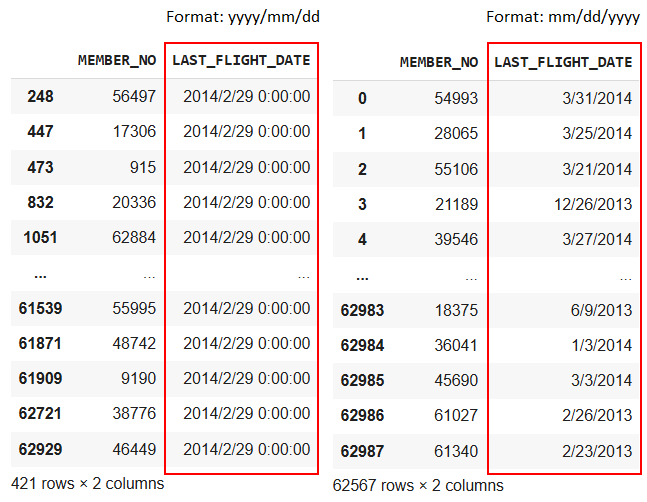

**Catatan:**
* Di sini tidak dilakukan drop outliers, karena walaupun ada outliers pada data numerik, tetapi masih logis secara bisnis. Sebagai contoh untuk FLIGHT_COUNT.

In [ ]:
# Hitung Z-score
z = np.abs(stats.zscore(df['FLIGHT_COUNT']))

# Ambil data dengan Z > 3 sebagai outlier
outlier = df[z > 3]
print("Outlier:\n", outlier[['MEMBER_NO', 'FLIGHT_COUNT']])

Outlier:
        MEMBER_NO  FLIGHT_COUNT
0          54993           210
1          28065           140
2          55106           135
4          39546           152
5          56972            92
...          ...           ...
12194      61661            57
13006      13390            54
14026      51949            63
14842      28104            63
16887      23563            56

[1425 rows x 2 columns]


In [ ]:
df['FLIGHT_COUNT'].describe()

,FLIGHT_COUNT
count,62988.000000
mean,11.839414
std,14.049471
min,2.000000
25%,3.000000
50%,7.000000
75%,15.000000
max,213.000000


Catatan:
* Untuk kolom FLIGHT_COUNT ini terdapat outliers: 1425 baris, tetapi jika dilihat data min max, sebenarnya masih mungkin.

## **RFM (Recency, Frequency & Monetary) Analysis**
* R = LAST_FLIGHT_DATE
* F = FLIGHT_COUNT
* M = Points_Sum

Di sini untuk Monetary digunakan Points_Sum karena tidak ada kolom yang menunjukkan langsung kepada berapa uang yang digunakan untuk belanja tiket oleh member (customer) tersebut. Diantara kolom-kolom yang ada Points_Sum yang paling mendekati pada pemahaman Monetary. Jumlah poin yang didapat customer akan berbanding lurus dengan uang yang dikeluarkan customer untuk pembelian tiket.

In [ ]:
# Periksa min max (setelah di-convert dari tipe string ke datetime)
df['LAST_FLIGHT_DATE'].min(), df['LAST_FLIGHT_DATE'].max()

(Timestamp('2012-04-01 00:00:00'), Timestamp('2014-03-31 00:00:00'))

Catatan:
* Data LAST_FLIGHT_DATE digunakan untuk menghitung Recency, data menunjukkan mulai 1-Apr-2012 sampai dengan 31-Mar-2014. Berarti setidaknya RFM analysis bisa dilakukan tanggal 01-Apr-2014 (sehari setelah transaksi terakhir), supaya tidak ada transaksi lain yang tertinggal.

###Recency

In [ ]:
# Hitung recency ==> MEMBER_NO --> CustomerID
present_day = df['LAST_FLIGHT_DATE'].max() + datetime.timedelta(days = 1)
print(present_day)

recency = df.groupby('MEMBER_NO').agg({'LAST_FLIGHT_DATE': lambda date: (present_day - date.max()).days
                                        }).reset_index()
recency.rename(columns={'MEMBER_NO': 'CustomerID', 'LAST_FLIGHT_DATE':'Recency'}, inplace=True)
recency['Recency'] = recency['Recency'].astype('Int64')
recency.head()

2014-04-01 00:00:00


,CustomerID,Recency
0,1,197
1,2,113
2,3,83
3,4,30
4,5,94


###Frequency & Monetary
* Frequency = FLIGHT_COUNT
* Monetary = Points_Sum

Di sini akan dibuat sebuah dataset baru khusus untuk analisis RFM, yang berisi MEMBER_NO (CustomerID), Recency --> hasil perhitungan sebelumnya, Frequency --> FLIGHT_COUNT, Monetary --> Points_Sum. Ditambah dengan kolom-kolom hasil perhitungan RFM.

In [ ]:
df_rfm = df[['MEMBER_NO', 'FLIGHT_COUNT', 'Points_Sum']]
df_rfm = df_rfm.rename(columns={'MEMBER_NO': 'CustomerID', 'FLIGHT_COUNT': 'Frequency', 'Points_Sum': 'Monetary'})

df_rfm = recency.merge(df_rfm)
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,1,197,3,7035
1,2,113,24,16210
2,3,83,9,85008
3,4,30,12,10826
4,5,94,3,2329


### Calculate RFM Score

In [ ]:
# Menentukan percentile
def percent_rank(series):
  return series.rank(pct=True, method='min')

df_rfm['RecencyPercentile'] = percent_rank(-df_rfm['Recency'])
df_rfm['FrequencyPercentile'] = percent_rank(df_rfm['Frequency'])
df_rfm['MonetaryPercentile'] = percent_rank(df_rfm['Monetary'])

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,RecencyPercentile,FrequencyPercentile,MonetaryPercentile
0,1,197,3,7035,0.330507,0.165031,0.534816
1,2,113,24,16210,0.482441,0.870134,0.782800
2,3,83,9,85008,0.554804,0.575268,0.987458
3,4,30,12,10826,0.744173,0.675240,0.670874
4,5,94,3,2329,0.530196,0.165031,0.203055


In [ ]:
# Calculate RFM score based on percentile
def calculate_score(percentile):
  if percentile >= 0.8:
    return 5
  if percentile >= 0.6:
    return 4
  if percentile >= 0.4:
    return 3
  if percentile >= 0.2:
    return 2
  else:
    return 1

df_rfm['RecencyScore'] = df_rfm['RecencyPercentile'].apply(calculate_score)
df_rfm['FrequencyScore'] = df_rfm['FrequencyPercentile'].apply(calculate_score)
df_rfm['MonetaryScore'] = df_rfm['MonetaryPercentile'].apply(calculate_score)

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,RecencyPercentile,FrequencyPercentile,MonetaryPercentile,RecencyScore,FrequencyScore,MonetaryScore
0,1,197,3,7035,0.330507,0.165031,0.534816,2,1,3
1,2,113,24,16210,0.482441,0.870134,0.782800,3,5,4
2,3,83,9,85008,0.554804,0.575268,0.987458,3,3,5
3,4,30,12,10826,0.744173,0.675240,0.670874,4,4,4
4,5,94,3,2329,0.530196,0.165031,0.203055,3,1,2


###Customer Segmentation by RFM Score

**Table of RFM Customer Segmentation**

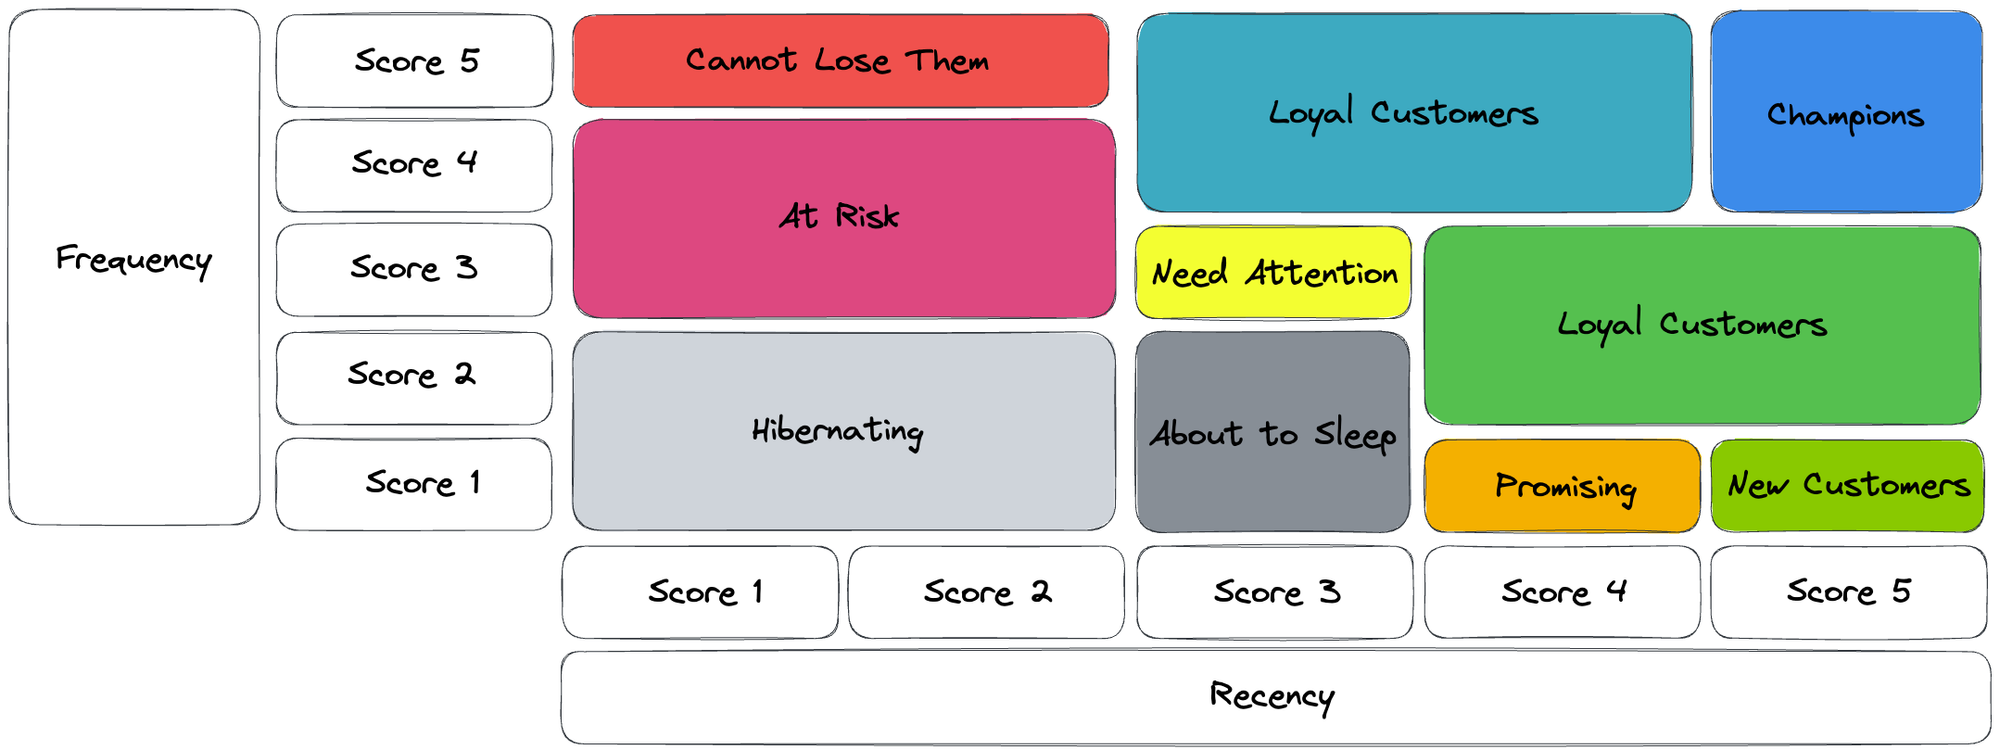

In [ ]:
# Customer segmentation
def rfm_segmentation(df):
   conditions = [
       (df['RecencyScore'] == 5) & (df['FrequencyScore'] >= 4), # Champions
       (df['RecencyScore'].isin([4, 5])) & (df['FrequencyScore'].isin([2, 3])) | # 'Loyal Customers' - condition 1
       (df['RecencyScore'].isin([3, 4])) & (df['FrequencyScore'].isin([4, 5])),  # 'Loyal Customers' - condition 2
       (df['RecencyScore'] == 5) & (df['FrequencyScore'] == 1), # 'New Customers'
       (df['RecencyScore'] == 4) & (df['FrequencyScore'] == 1), # 'Promising'
       (df['RecencyScore'] == 3) & (df['FrequencyScore'] == 3), # 'Need Attention'
       (df['RecencyScore'] == 3) & (df['FrequencyScore'] <= 2), # 'About to Sleep'
       (df['RecencyScore'] <= 2) & (df['FrequencyScore'] == 5), # 'Cannot Lose Them'
       (df['RecencyScore'] <= 2) & (df['FrequencyScore'].isin([3, 4])), # 'At Risk'
       (df['RecencyScore'] <= 2) & (df['FrequencyScore'] <= 2) # 'Hibernating'

   ]

   choices = [
       'Champions',
       'Loyal Customers',
       'New Customers',
       'Promising',
       'Need Attention',
       'About to Sleep',
       'Cannot Lose Them',
       'At Risk',
       'Hibernating'
   ]

   df['Segment'] = np.select(conditions, choices, default='Other')
   return df

df_rfm = rfm_segmentation(df_rfm)
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,RecencyPercentile,FrequencyPercentile,MonetaryPercentile,RecencyScore,FrequencyScore,MonetaryScore,Segment
0,1,197,3,7035,0.330507,0.165031,0.534816,2,1,3,Hibernating
1,2,113,24,16210,0.482441,0.870134,0.782800,3,5,4,Loyal Customers
2,3,83,9,85008,0.554804,0.575268,0.987458,3,3,5,Need Attention
3,4,30,12,10826,0.744173,0.675240,0.670874,4,4,4,Loyal Customers
4,5,94,3,2329,0.530196,0.165031,0.203055,3,1,2,About to Sleep


### Summary of RFM Customer Segmentation

In [ ]:
df_rfm.Segment.value_counts()

,count
Segment,
Loyal Customers,18550
Hibernating,17379
Champions,9095
At Risk,7137
About to Sleep,4396
Need Attention,3108
Promising,1727
New Customers,878
Cannot Lose Them,718


###Analysis & Recommendation

####Analysis
| Segmen | Analisis |
|--------|---------|
| Loyal Customers (29,45%) | Merupakan basis terbesar pelanggan. Mereka sering belanja, berkontribusi besar bagi perusahaan, tapi belum jadi “champions”. Peluang: bisa di-upgrade menjadi Champions melalui program loyalitas, upsell, atau cross-sell.|
| Hibernating (27,58%) | Merupakan hampir sepertiga pelanggan, namun sudah lama tidak aktif. Risiko: segmen ini bisa hilang permanen kalau tidak ada upaya reaktivasi. Tindakan: lakukan campaign re-engagement, misal dengan: voucher, promo terbatas, personalisasi email.|
| Champions (14,45%) | Merupakan pelanggan terbaik: terbaru, paling sering, paling banyak berkontribusi. Harus dijaga melalui program eksklusif, VIP treatment, early access produk. |
| At Risk (11,33%) | Sebelumnya bernilai tinggi tapi belakangan berhenti. Tindakan: lakukan kampanye win-back, seperti: diskon personal, reminder produk favorit. |
| About to Sleep (6,98%) | Aktivitas menurun, kemungkinan segera churn. Tindakan: tawarkan insentif kecil untuk kembali bertransaksi, seperti: free shipping, poin bonus.|
| Need Attention (4,94%) | Pernah aktif, tapi engagement rendah. Tindakan: beri alasan untuk lebih sering belanja → program referral, bundling.|
| Promising (2,74%) | Baru mulai aktif, berpotensi jadi loyal. Tindakan: membina dan menjaaga pelanggan kelas ini dengan program onboarding, edukasi produk, promo sambutan.|
| New Customers (1,39%) | Baru pertama kali transaksi. Tindakan: pastikan pengalaman pertama bagus, seperti: welcome voucher, email follow-up.|
| Cannot Lose Them (1,14%) | Pernah sangat bernilai, sekarang berhenti. Segmen kecil tapi penting. Tindakan: pendekatan personal, seperti: telepon/WA langsung, account manager. |

####Recommendation
|Segmen | Rekomendasi |
|-------|-------------|
|Champions + Loyal Customers (43,90%) → Prioritas 1 | Perlu dijaga dengan baik karena merupakan "aset" penting perusahaan, berikan penghargaan, dan jadikan brand advocate. Buat program “member exclusive” agar mereka semakin diprioritaskan dan terikat.|
|At Risk + Cannot Lose Them (12,47%) → Prioritas 2 |Segmen ini bernilai tinggi tapi terancam hilang. Gunakan pendekatan personal, seperti melalui: email khusus, customer service proaktif.|
|Hibernating + About to Sleep (34,56%) → Prioritas 3|Segmen besar tapi dorman. Campaign massal berbasis diskon/promo → tapi ukur cost vs benefit.|
|Promising + New Customers (4,13%)|Investasi masa depan. Program onboarding, welcome journey.|
|Need Attention (4,94%)|Segmen sedang → perlu di-push untuk naik kelas. Dorong mereka upgrade frekuensi belanja.|

####SWOT Analysis
|SWOT| Analysis|
|---|---|
|Strength|Basis pelanggan loyal dan champions cukup besar (43,90%) → modal kuat.|
|Weakness|Segmen dorman (hibernating) juga cukup besar (27,58%).|
|Opportunity|Promising + New Customers bisa diarahkan jadi Loyal.|
|Threat|At Risk + Cannot Lose Them perlu penanganan cepat agar tidak benar-benar churn.|


### 3D Plot of RFM Customer Segmentation

In [ ]:
!pip install plotly

In [ ]:
# Kode dibuat kak Nanda dan digunakan pada pembelajaran di kelas
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

def create_3d_rfm_plot(df):
    fig = px.scatter_3d(df,
                        x='RecencyScore',
                        y='FrequencyScore',
                        z='MonetaryScore',
                        color='Segment',
                        title='3D RFM Analysis - Interactive Plot',
                        labels={
                            'RecencyScore': 'Recency Score',
                            'FrequencyScore': 'Frequency Score',
                            'MonetaryScore': 'Monetary Score'
                        },
                        hover_data=['Segment'],
                        opacity=0.7,
                        size_max=10)

    fig.update_layout(
        scene=dict(
            xaxis_title='Recency Score',
            yaxis_title='Frequency Score',
            zaxis_title='Monetary Score',
            bgcolor='white',
            xaxis=dict(gridcolor='lightgray'),
            yaxis=dict(gridcolor='lightgray'),
            zaxis=dict(gridcolor='lightgray')
        ),
        width=800,
        height=600,
        title_x=0.5
    )

    fig.show()
    return fig

def create_enhanced_3d_rfm_plot(df):
    color_map = {
        'Champions': '#1f77b4',
        'Loyal Customers': '#2ca02c',
        'New Customers': '#ff7f0e',
        'Big Spenders': '#d62728',
        'Promising': '#9467bd',
        'About to Sleep': '#8c564b',
        'At Risk': '#e377c2',
        'Hibernating': '#7f7f7f',
        'Cannot Lose Them': '#bcbd22',
        'Others': '#17becf'
    }

    segment_counts = df['Segment'].value_counts()
    max_count = segment_counts.max()
    min_count = segment_counts.min()

    fig = go.Figure()

    for segment in df['Segment'].unique():
        segment_data = df[df['Segment'] == segment]
        count = segment_counts[segment]

        marker_size = 3 + (count - min_count) / (max_count - min_count) * 12

        opacity = 0.4 + (count - min_count) / (max_count - min_count) * 0.5

        fig.add_trace(go.Scatter3d(
            x=segment_data['RecencyScore'],
            y=segment_data['FrequencyScore'],
            z=segment_data['MonetaryScore'],
            mode='markers',
            marker=dict(
                size=marker_size,
                color=color_map.get(segment, '#17becf'),
                opacity=opacity,
                line=dict(width=0.5, color='white')
            ),
            name=f"{segment} ({count})",
            hovertemplate=
            '<b>%{text}</b><br>' +
            'Count: ' + str(count) + '<br>' +
            'Recency: %{x}<br>' +
            'Frequency: %{y}<br>' +
            'Monetary: %{z}<br>' +
            '<extra></extra>',
            text=[f"{segment} ({count})"] * len(segment_data)
        ))

    fig.update_layout(
        title={
            'text': '3D RFM Customer Segmentation Analysis',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        scene=dict(
            xaxis_title='Recency Score (1-5)',
            yaxis_title='Frequency Score (1-5)',
            zaxis_title='Monetary Score (1-5)',
            bgcolor='rgba(240,240,240,0.1)',
            xaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                backgroundcolor='rgba(230,230,230,0.3)'
            ),
            yaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                backgroundcolor='rgba(230,230,230,0.3)'
            ),
            zaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                backgroundcolor='rgba(230,230,230,0.3)'
            ),
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        width=900,
        height=700,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='gray',
            borderwidth=1
        )
    )

    fig.show()
    return fig

def create_rfm_dashboard(df):
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{'type': 'scatter3d', 'colspan': 2}, None],
               [{'type': 'scatter'}, {'type': 'scatter'}]],
        subplot_titles=('3D RFM Analysis', 'Recency vs Frequency', 'Recency vs Monetary'),
        vertical_spacing=0.1
    )

    for segment in df['Segment'].unique():
        segment_data = df[df['Segment'] == segment]
        fig.add_trace(
            go.Scatter3d(
                x=segment_data['RecencyScore'],
                y=segment_data['FrequencyScore'],
                z=segment_data['MonetaryScore'],
                mode='markers',
                name=segment,
                marker=dict(size=4, opacity=0.7),
                showlegend=True
            ),
            row=1, col=1
        )

    for segment in df['Segment'].unique():
        segment_data = df[df['Segment'] == segment]

        fig.add_trace(
            go.Scatter(
                x=segment_data['RecencyScore'],
                y=segment_data['FrequencyScore'],
                mode='markers',
                name=segment,
                showlegend=False,
                marker=dict(size=4, opacity=0.7)
            ),
            row=2, col=1
        )

        fig.add_trace(
            go.Scatter(
                x=segment_data['RecencyScore'],
                y=segment_data['MonetaryScore'],
                mode='markers',
                name=segment,
                showlegend=False,
                marker=dict(size=4, opacity=0.7)
            ),
            row=2, col=2
        )

    fig.update_layout(height=800, title_text="RFM Analysis Dashboard")
    fig.show()
    return fig

def create_rfm_bucket_plot(df):
    # Create RFM bucket combinations
    df['RFM_Bucket'] = df['RecencyScore'].astype(str) + df['FrequencyScore'].astype(str) + df['MonetaryScore'].astype(str)

    bucket_stats = df.groupby('RFM_Bucket').agg({
        'RecencyScore': 'mean',
        'FrequencyScore': 'mean',
        'MonetaryScore': 'mean',
        'Segment': 'first'
    }).reset_index()
    bucket_stats['Count'] = df['RFM_Bucket'].value_counts().values

    color_map = {
        'Champions': '#1f77b4', 'Loyal Customers': '#2ca02c', 'New Customers': '#ff7f0e',
        'Big Spenders': '#d62728', 'Promising': '#9467bd', 'About to Sleep': '#8c564b',
        'At Risk': '#e377c2', 'Hibernating': '#7f7f7f', 'Cannot Lose Them': '#bcbd22',
        'Others': '#17becf'
    }

    max_count = bucket_stats['Count'].max()
    min_count = bucket_stats['Count'].min()

    bucket_stats['Size'] = 5 + (bucket_stats['Count'] - min_count) / (max_count - min_count) * 25
    bucket_stats['Opacity'] = 0.5 + (bucket_stats['Count'] - min_count) / (max_count - min_count) * 0.4

    fig = go.Figure()

    for _, row in bucket_stats.iterrows():
        fig.add_trace(go.Scatter3d(
            x=[row['RecencyScore']],
            y=[row['FrequencyScore']],
            z=[row['MonetaryScore']],
            mode='markers',
            marker=dict(
                size=row['Size'],
                color=color_map.get(row['Segment'], '#17becf'),
                opacity=row['Opacity'],
                line=dict(width=2, color='white'),
                symbol='circle'
            ),
            name=f"{row['RFM_Bucket']} ({row['Count']})",
            hovertemplate=
            '<b>RFM Bucket: %{text}</b><br>' +
            f"Count: {row['Count']}<br>" +
            f"Segment: {row['Segment']}<br>" +
            'R: %{x} | F: %{y} | M: %{z}<br>' +
            '<extra></extra>',
            text=[row['RFM_Bucket']],
            showlegend=False
        ))

    segments_in_data = bucket_stats['Segment'].unique()
    for segment in segments_in_data:
        fig.add_trace(go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode='markers',
            marker=dict(
                size=10,
                color=color_map.get(segment, '#17becf'),
                opacity=0.8
            ),
            name=segment,
            showlegend=True,
            hoverinfo='skip'
        ))

    fig.update_layout(
        title={
            'text': 'RFM Buckets - Size & Opacity by Customer Count',
            'x': 0.5, 'xanchor': 'center', 'font': {'size': 20}
        },
        scene=dict(
            xaxis_title='Recency Score (1-5)',
            yaxis_title='Frequency Score (1-5)',
            zaxis_title='Monetary Score (1-5)',
            xaxis=dict(dtick=1, range=[0.5, 5.5]),
            yaxis=dict(dtick=1, range=[0.5, 5.5]),
            zaxis=dict(dtick=1, range=[0.5, 5.5]),
            bgcolor='rgba(240,240,240,0.1)',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
        ),
        width=900, height=700
    )

    fig.show()
    return fig, bucket_stats

# Basic 3D plot
fig1 = create_3d_rfm_plot(df_rfm)

# Enhanced 3D plot with size/opacity based on segment counts
# fig2 = create_enhanced_3d_rfm_plot(data)

# RFM bucket visualization with size based on exact bucket counts
# fig3, bucket_data = create_rfm_bucket_plot(data)

# Complete dashboard with multiple views
# fig4 = create_rfm_dashboard(data)

# To save the plot as HTML (optional)
# fig.write_html("rfm_3d_analysis.html")

## **K-Means**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc={'figure.figsize':(20.7, 8.27)})
sns.set_style('whitegrid')
sns.color_palette('dark')
plt.style.use('fivethirtyeight')

In [ ]:
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,2006-11-02,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,2014-03-31,1,3.483254,18,34,0.961639,619760,50
1,28065,2007-02-19,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,2014-03-25,7,5.194245,17,29,1.252314,415768,33
2,55106,2007-02-01,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,2014-03-21,11,5.298507,18,20,1.254676,406361,26
3,21189,2008-08-22,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,2013-12-26,97,27.863636,73,11,1.090870,372204,12
4,39546,2009-04-10,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,2014-03-27,5,4.788079,47,27,0.970658,338813,39


###Column Analysis

Analisis kolom dilakukan untuk memilih kira-kira kolom mana yang akan digunakan pada saat dilkukan pemodelan.

Kolom-kolom yang tidak digunakan:
1. MEMBER_NO: akan dijadikan indeks, karena tidak relevan
2. FIRST_FLIGHT_DATE: sudah terwakili dengan LAST_FLIGHT_DATE.
3. WORK_CITY: data terlalu kotor --> bisa membingungkan
4. WORK_PROVINCE: data terlalu kotor --> bisa membingungkan
5. WORK_COUNTRY: data terlalu kotor --> bisa membingungkan
6. LOAD_TIME: tanggal data di-upload --> tidak relevan, bukan data bisnis.
7. BP_SUM: karena ini adalah sebuah rencana, jadi belum terealisasi.
8. LAST_FLIGHT_DATE: digantikan dengan recency --> diambil dari tabel RFM

Kolom-kolom yang digunakan (sebelum dieliminir karena alasan lainnya):
1. FFP_DATE: digunakan untuk menghitung seberapa lama menjadi anggota. Formula: current date - FFP_DATE
2. GENDER: bisa di-encoding OHE.
3. FFP_TIER: klas keanggotan --> seharusnya setara dengan FFP_DATE, perlu dilihat korelasinya.
4. AGE
5. FLIGHT_COUNT
6. SUM_YR_1: sepertinya bisa saling mewakili dengan SUM_YR_2
7. SUM_YR_2
8. SEG_KM_SUM
9. LAST_TO_END  
10. AVG_INTERVAL: bisa diwaki oleh MAX_INTERVAL
11. MAX_INTERVAL
12. EXCHANGE_COUNT
13. avg_discount
14. Points_Sum
15. Point_NotFlight

###Choose related columns for the next process
* Kolom-kolom tidak perlu dibuang saja

In [ ]:
# Kolom-kolom ini tidak diperlukan pada proses berikutnya, kecuali MEMBER_NO
columns_to_drop = ['LOAD_TIME', 'BP_SUM', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'FIRST_FLIGHT_DATE', 'LAST_FLIGHT_DATE']

# Buat salinan df untuk k-means
df_km = df.drop(columns=columns_to_drop).copy()
df_km.head()

,MEMBER_NO,FFP_DATE,GENDER,FFP_TIER,AGE,FLIGHT_COUNT,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,2006-11-02,Male,6,31.0,210,239560.0,234188.0,580717,1,3.483254,18,34,0.961639,619760,50
1,28065,2007-02-19,Male,6,42.0,140,171483.0,167434.0,293678,7,5.194245,17,29,1.252314,415768,33
2,55106,2007-02-01,Male,6,40.0,135,163618.0,164982.0,283712,11,5.298507,18,20,1.254676,406361,26
3,21189,2008-08-22,Male,5,64.0,23,116350.0,125500.0,281336,97,27.863636,73,11,1.090870,372204,12
4,39546,2009-04-10,Male,6,48.0,152,124560.0,130702.0,309928,5,4.788079,47,27,0.970658,338813,39


In [ ]:
df_km.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   MEMBER_NO        62988 non-null  int64         
 1   FFP_DATE         62988 non-null  datetime64[ns]
 2   GENDER           62985 non-null  object        
 3   FFP_TIER         62988 non-null  int64         
 4   AGE              62568 non-null  float64       
 5   FLIGHT_COUNT     62988 non-null  int64         
 6   SUM_YR_1         62437 non-null  float64       
 7   SUM_YR_2         62850 non-null  float64       
 8   SEG_KM_SUM       62988 non-null  int64         
 9   LAST_TO_END      62988 non-null  int64         
 10  AVG_INTERVAL     62988 non-null  float64       
 11  MAX_INTERVAL     62988 non-null  int64         
 12  EXCHANGE_COUNT   62988 non-null  int64         
 13  avg_discount     62988 non-null  float64       
 14  Points_Sum       62988 non-null  int64

In [ ]:
# ganti nama kolom MEMBER_No --> CustomerID
df_km.rename(columns={'MEMBER_NO':'CustomerID'}, inplace=True)

####Enrich data: Recency & DaysMember
* DaysMember: lamanya hari keanggotaan FFP.

In [ ]:
'''
  Ambil kolom Recency dari pekerjaan RFM untuk menggantikan LAST_FLIGHT_DATE
  karena LAST_FLIGHT_DATE sudah tidak relevan untuk analisa dengan K-Means yang menggunakan
  pendekatan jarak (euclidean). Sementara perhitungan Recency lebih relevan.
'''
df_km = pd.merge(df_km, df_rfm[['CustomerID', 'Recency']], on='CustomerID', how='inner')

In [ ]:
'''
  Menghitung durasi membership dari FFP_DATE dari tanggal sekarang
  Sama persoalannya dengan LAST_FLIGHT_DATE
  df_km['DaysMember'] = (pd.to_datetime('today') - pd.to_datetime(df_km['FFP_DATE'])).dt.days
'''
max_LastFlightDate = df['LAST_FLIGHT_DATE'].max()
df_km['DaysMember'] = (max_LastFlightDate - pd.to_datetime(df_km['FFP_DATE'])).dt.days

In [ ]:
#Drop kolom FFP_DATE --> sudah digantikan dengan DaysMember
df_km.drop(columns=['FFP_DATE'], inplace=True)
df_km.head(10)

,CustomerID,GENDER,FFP_TIER,AGE,FLIGHT_COUNT,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight,Recency,DaysMember
0,54993,Male,6,31.0,210,239560.0,234188.0,580717,1,3.483254,18,34,0.961639,619760,50,1,2706
1,28065,Male,6,42.0,140,171483.0,167434.0,293678,7,5.194245,17,29,1.252314,415768,33,7,2597
2,55106,Male,6,40.0,135,163618.0,164982.0,283712,11,5.298507,18,20,1.254676,406361,26,11,2615
3,21189,Male,5,64.0,23,116350.0,125500.0,281336,97,27.863636,73,11,1.090870,372204,12,96,2047
4,39546,Male,6,48.0,152,124560.0,130702.0,309928,5,4.788079,47,27,0.970658,338813,39,5,1816
5,56972,Male,6,64.0,92,112364.0,76946.0,294585,79,7.043956,52,10,0.967692,343121,15,78,2241
6,44924,Male,6,46.0,101,120500.0,114469.0,287042,1,7.190000,28,20,0.965347,298873,29,1,2931
7,22631,Female,6,50.0,73,82440.0,114971.0,287230,3,10.111111,45,7,0.962070,351198,14,3,1452
8,32197,Male,5,50.0,56,72596.0,87401.0,321489,6,13.054545,94,5,0.828478,295158,7,6,1028
9,31645,Female,6,43.0,64,85258.0,60267.0,375074,15,11.333333,73,13,0.708010,251907,16,15,1365


###Data Preprocessing

####Check features correlation

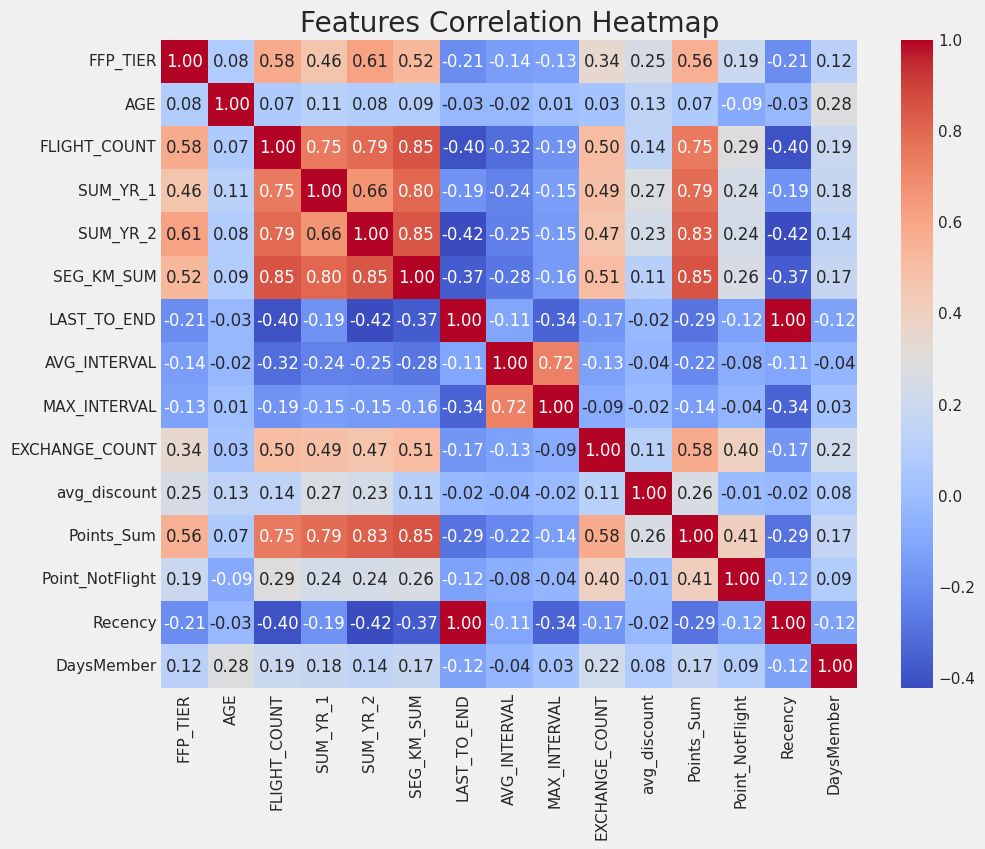

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Copy data dengan membuang 2 kolom
df_corr = df = df_km.drop(columns=['CustomerID', 'GENDER'])

# Hitung korelasi
corr_matrix = df_corr.corr()

# Buat heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, annot_kws={"size": 12})
plt.title("Features Correlation Heatmap")
plt.show()

In [ ]:
# drop kolom SUM_YR_1 dan SUM_YR_2
df_km = df_km.drop(columns=['SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'Points_Sum', 'Recency', 'MAX_INTERVAL'])

In [ ]:
df_km.head()

,CustomerID,GENDER,FFP_TIER,AGE,FLIGHT_COUNT,LAST_TO_END,AVG_INTERVAL,EXCHANGE_COUNT,avg_discount,Point_NotFlight,DaysMember
0,54993,Male,6,31.0,210,1,3.483254,34,0.961639,50,2706
1,28065,Male,6,42.0,140,7,5.194245,29,1.252314,33,2597
2,55106,Male,6,40.0,135,11,5.298507,20,1.254676,26,2615
3,21189,Male,5,64.0,23,97,27.863636,11,1.090870,12,2047
4,39546,Male,6,48.0,152,5,4.788079,27,0.970658,39,1816


Catatan:
* Dari heatmap correlation tampak ada sejumlah feature yang memiliki korelasi yang kuat. Disini digunakan pendekatan > 70, maka sejumlah feature akan dieliminir.
* Yang menarik adalah dimana: Recency dan LAST_TO_END menunjukkan korelasi sempurna, yakni: 1, ini berarti Recency = LAST_TO_END. Jadi sebenarnya ketika kita melakukan RFM Analysis, kita tidak perlu menghitung lagi nilai Recency berdasarkan LAST_FLIGHT_DATE. Tetapi jika tidak dilakukan itu, maka case tanggal (bertipe string): 29/2/2014 tidak akan ketahuan. --> sebuah pembelajaran penting.

####Imputation & encoding: GENDER & FFP_TIER

In [ ]:
# Hitung modus
mod_gender = df_km['GENDER'].mode()[0]

# Isi NaN dengan modus
df_km['GENDER'] = df_km['GENDER'].fillna(mod_gender)

# Lakukan OHE alih2 label encoding
# FFP_TIER ini sebenarnya kategorikal
cols_ohe=['GENDER', 'FFP_TIER']
df_km = pd.get_dummies(df_km, columns=cols_ohe)

In [ ]:
df_km.head(10)

,CustomerID,AGE,FLIGHT_COUNT,LAST_TO_END,AVG_INTERVAL,EXCHANGE_COUNT,avg_discount,Point_NotFlight,DaysMember,GENDER_Female,GENDER_Male,FFP_TIER_4,FFP_TIER_5,FFP_TIER_6
0,54993,31.0,210,1,3.483254,34,0.961639,50,2706,False,True,False,False,True
1,28065,42.0,140,7,5.194245,29,1.252314,33,2597,False,True,False,False,True
2,55106,40.0,135,11,5.298507,20,1.254676,26,2615,False,True,False,False,True
3,21189,64.0,23,97,27.863636,11,1.090870,12,2047,False,True,False,True,False
4,39546,48.0,152,5,4.788079,27,0.970658,39,1816,False,True,False,False,True
5,56972,64.0,92,79,7.043956,10,0.967692,15,2241,False,True,False,False,True
6,44924,46.0,101,1,7.190000,20,0.965347,29,2931,False,True,False,False,True
7,22631,50.0,73,3,10.111111,7,0.962070,14,1452,True,False,False,False,True
8,32197,50.0,56,6,13.054545,5,0.828478,7,1028,False,True,False,True,False
9,31645,43.0,64,15,11.333333,13,0.708010,16,1365,True,False,False,False,True


####Imputation & encoding: AGE

In [ ]:
# Check kolom-kolom yang masih mengandung nilai null
misval = df_km.isna().sum().reset_index()
misval.columns = ['Column Name', 'Missing Values']
misval[misval['Missing Values'] > 0]

,Column Name,Missing Values
1,AGE,420


Catatan:
* Sampai di sini semua kolom sudah terwakili dengan angka, tetapi masih ada missing value yang harus di-imputasi.

In [ ]:
# Imputasi missing values by median
col_mv = ['AGE']

for col in col_mv:
  df_km[col] = df_km[col].fillna(df_km[col].median())

In [ ]:
# Check kolom-kolom yang masih mengandung nilai null, jika ada
misval = df_km.isnull().sum()
print("Columns with missing values after imputation:")
print(misval[misval > 0])

Columns with missing values after imputation:
Series([], dtype: int64)


In [ ]:
df_km.head(10)

,CustomerID,AGE,FLIGHT_COUNT,LAST_TO_END,AVG_INTERVAL,EXCHANGE_COUNT,avg_discount,Point_NotFlight,DaysMember,GENDER_Female,GENDER_Male,FFP_TIER_4,FFP_TIER_5,FFP_TIER_6
0,54993,31.0,210,1,3.483254,34,0.961639,50,2706,False,True,False,False,True
1,28065,42.0,140,7,5.194245,29,1.252314,33,2597,False,True,False,False,True
2,55106,40.0,135,11,5.298507,20,1.254676,26,2615,False,True,False,False,True
3,21189,64.0,23,97,27.863636,11,1.090870,12,2047,False,True,False,True,False
4,39546,48.0,152,5,4.788079,27,0.970658,39,1816,False,True,False,False,True
5,56972,64.0,92,79,7.043956,10,0.967692,15,2241,False,True,False,False,True
6,44924,46.0,101,1,7.190000,20,0.965347,29,2931,False,True,False,False,True
7,22631,50.0,73,3,10.111111,7,0.962070,14,1452,True,False,False,False,True
8,32197,50.0,56,6,13.054545,5,0.828478,7,1028,False,True,False,True,False
9,31645,43.0,64,15,11.333333,13,0.708010,16,1365,True,False,False,False,True


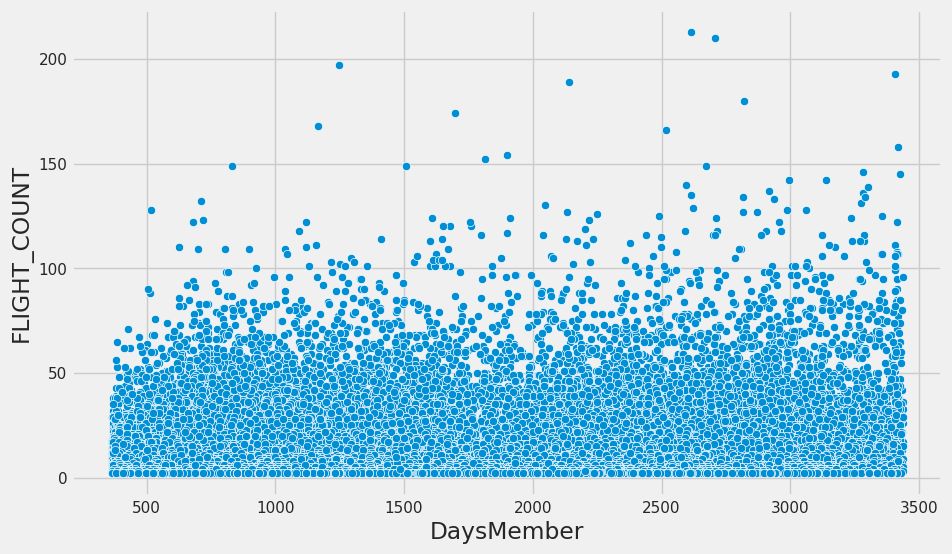

In [ ]:
'''
  Digunakan feature DaysMember=lamanya pelanggan menjadi member FFP dikaitkan dengan banyaknya
  penerbangan yang telah dilakukan selama menjadi member. --> Diharapkan loyalitas sebagai member
  akan menunjukkan jumlah penerbangan semakin banyak.. --> akan diuji/ dicari tahu dengan
  pendekatan clustering K-Means.
'''

feature_x = 'DaysMember'
feature_y = 'FLIGHT_COUNT'

fig, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data=df_km, x=feature_x, y=feature_y)
plt.show()

In [ ]:
# CustomerID dijadikan indeks
df_km.set_index('CustomerID', inplace=True)
df_km.head()

,AGE,FLIGHT_COUNT,LAST_TO_END,AVG_INTERVAL,EXCHANGE_COUNT,avg_discount,Point_NotFlight,DaysMember,GENDER_Female,GENDER_Male,FFP_TIER_4,FFP_TIER_5,FFP_TIER_6
CustomerID,,,,,,,,,,,,,
54993,31.0,210,1,3.483254,34,0.961639,50,2706,False,True,False,False,True
28065,42.0,140,7,5.194245,29,1.252314,33,2597,False,True,False,False,True
55106,40.0,135,11,5.298507,20,1.254676,26,2615,False,True,False,False,True
21189,64.0,23,97,27.863636,11,1.090870,12,2047,False,True,False,True,False
39546,48.0,152,5,4.788079,27,0.970658,39,1816,False,True,False,False,True


In [ ]:
df_km.sort_index().head()

,AGE,FLIGHT_COUNT,LAST_TO_END,AVG_INTERVAL,EXCHANGE_COUNT,avg_discount,Point_NotFlight,DaysMember,GENDER_Female,GENDER_Male,FFP_TIER_4,FFP_TIER_5,FFP_TIER_6
CustomerID,,,,,,,,,,,,,
1,40.0,3,198,4.000000,0,0.658303,0,2922,False,True,True,False,False
2,52.0,24,114,24.347826,0,0.615947,0,2922,False,True,True,False,False
3,52.0,9,84,80.125000,2,0.522271,5,2915,True,False,True,False,False
4,45.0,12,30,52.090909,0,0.511084,13,2790,False,True,True,False,False
5,57.0,3,95,300.500000,0,0.954166,0,2244,False,True,True,False,False


####Scaling - Stardardization

In [ ]:
# Gunakan Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_km)

df_km_scaled = pd.DataFrame(data = features_scaled, columns = df_km.columns)
df_km_scaled.head()

,AGE,FLIGHT_COUNT,LAST_TO_END,AVG_INTERVAL,EXCHANGE_COUNT,avg_discount,Point_NotFlight,DaysMember,GENDER_Female,GENDER_Male,FFP_TIER_4,FFP_TIER_5,FFP_TIER_6
0,-1.163692,14.104600,-0.952668,-0.829061,29.648208,1.294761,6.419225,1.441190,-0.555442,0.555442,-3.434711,-0.239203,6.374260
1,-0.047343,9.122166,-0.920027,-0.806989,25.246781,2.862377,4.110730,1.312533,-0.555442,0.555442,-3.434711,-0.239203,6.374260
2,-0.250316,8.766278,-0.898267,-0.805644,17.324213,2.875110,3.160173,1.333779,-0.555442,0.555442,-3.434711,-0.239203,6.374260
3,2.185353,0.794384,-0.430420,-0.514545,9.401645,1.991703,1.259059,0.663348,-0.555442,0.555442,-3.434711,4.180547,-0.156881
4,0.561574,9.976297,-0.930907,-0.812228,23.486211,1.343400,4.925493,0.390690,-0.555442,0.555442,-3.434711,-0.239203,6.374260


Catatan:
* Semua nilai kolom sudah tidak ada missing values, sudah di OHE, tanggal sudah ditransformasi atau diganti dengan nilai lain, seperti Recency. --> Tapi Recency tereliminir juga oleh LAST_TO_END.

###Check optimal number of cluster

####Elbow Method

In [ ]:
from sklearn.cluster import KMeans
list_inertia = []

for i in range(2, 11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(df_km_scaled[[feature_x,feature_y]])
  nilai_inertia = kmeans.inertia_
  list_inertia.append(nilai_inertia)
  print(f'cluster ke {i} dengan nilai inertia {round(nilai_inertia, 2)}')

cluster ke 2 dengan nilai inertia 74342.97
cluster ke 3 dengan nilai inertia 41838.65
cluster ke 4 dengan nilai inertia 35184.69
cluster ke 5 dengan nilai inertia 27164.72
cluster ke 6 dengan nilai inertia 21578.83
cluster ke 7 dengan nilai inertia 18958.5
cluster ke 8 dengan nilai inertia 16250.0
cluster ke 9 dengan nilai inertia 14269.45
cluster ke 10 dengan nilai inertia 13215.88


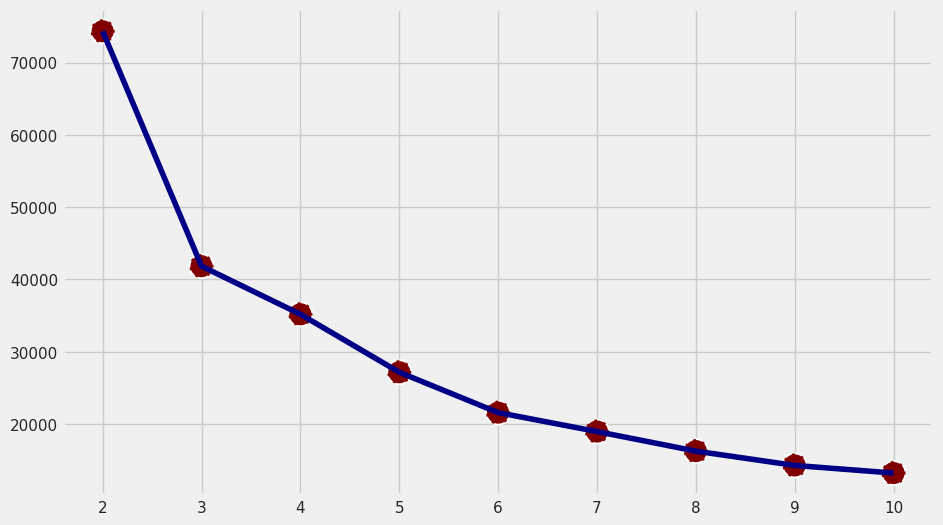

In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(x=range(2, 11), y=list_inertia, color='#000087', linewidth=4)
sns.scatterplot(x=range(2, 11), y=list_inertia, s=300, color='#800000', linestyle='--')

plt.show()

Catatan:
* k=2 → inertia masih sangat besar (~75,000)
* k=3 → turun drastis (~40,000)
* k=4 → turun lagi tapi lebih landai (~36,000)
* k=5 → mulai landai (~29,000)
* k=6–10 → penurunannya kecil-kecil (hampir datar)

Kemungkinan titik siku ada di antara 3 dan 4. Uji lebih lanjut dengan silhouette.

####Silhouette score

In [ ]:
from sklearn.metrics import silhouette_score

range_n_clusters = list(range(2,11))
print(range_n_clusters)

[2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
# Basically score from -1 sampai 1
arr_silhouette_score_euclidean = []
for i in range_n_clusters:
   kmeans = KMeans(n_clusters=i).fit(df_km_scaled[[feature_x, feature_y]])
   preds = kmeans.predict(df_km_scaled[[feature_x, feature_y]])

   score_euclidean = silhouette_score(df_km_scaled[[feature_x, feature_y]], preds, metric='euclidean')
   arr_silhouette_score_euclidean.append(score_euclidean)

Catatan:
* Di sini proses bisa cukup lama (>10 menit).

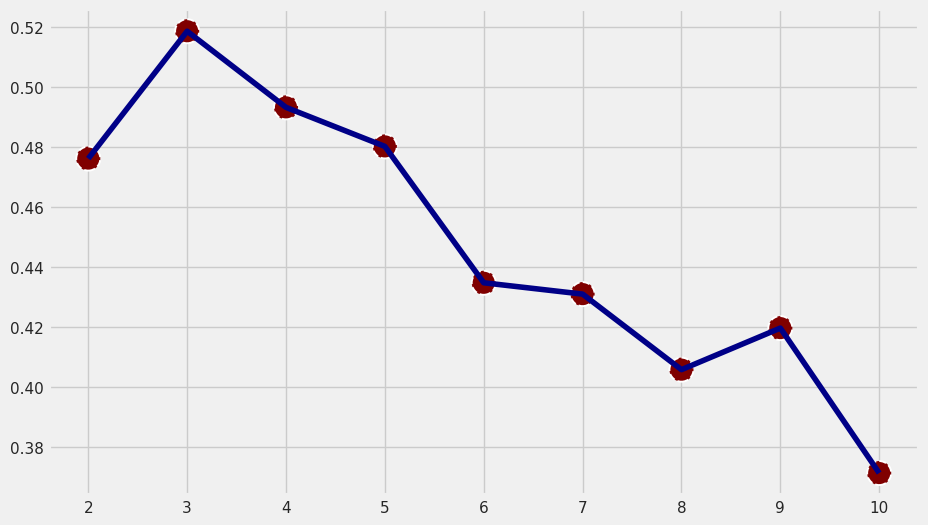

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=range(2,11), y=arr_silhouette_score_euclidean, color='#000087', linewidth=4)
sns.scatterplot(x=range(2,11), y=arr_silhouette_score_euclidean, s=300, color='#800000', linestyle='--')

plt.show()

Catatan:
* Misal disepakati akan digunakan 3 cluster sesuai silhouette score.

###Clustering by K-Means (K=3)

####Cluster the data

In [ ]:
# KMeans 3 Cluster
nc = 3
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=nc, random_state=42)
kmeans.fit(df_km_scaled[[feature_x, feature_y]])

df_km_scaled['Cluster_K3'] = kmeans.labels_
df_km_scaled.head()

,AGE,FLIGHT_COUNT,LAST_TO_END,AVG_INTERVAL,EXCHANGE_COUNT,avg_discount,Point_NotFlight,DaysMember,GENDER_Female,GENDER_Male,FFP_TIER_4,FFP_TIER_5,FFP_TIER_6,Cluster_K3
0,-1.163692,14.104600,-0.952668,-0.829061,29.648208,1.294761,6.419225,1.441190,-0.555442,0.555442,-3.434711,-0.239203,6.374260,2
1,-0.047343,9.122166,-0.920027,-0.806989,25.246781,2.862377,4.110730,1.312533,-0.555442,0.555442,-3.434711,-0.239203,6.374260,2
2,-0.250316,8.766278,-0.898267,-0.805644,17.324213,2.875110,3.160173,1.333779,-0.555442,0.555442,-3.434711,-0.239203,6.374260,2
3,2.185353,0.794384,-0.430420,-0.514545,9.401645,1.991703,1.259059,0.663348,-0.555442,0.555442,-3.434711,4.180547,-0.156881,0
4,0.561574,9.976297,-0.930907,-0.812228,23.486211,1.343400,4.925493,0.390690,-0.555442,0.555442,-3.434711,-0.239203,6.374260,2


In [ ]:
df_km_scaled[['Cluster_K3']].value_counts().sort_index()

,count
Cluster_K3,
0,21068
1,36835
2,5085


####Plot cluster (customer segmentation)

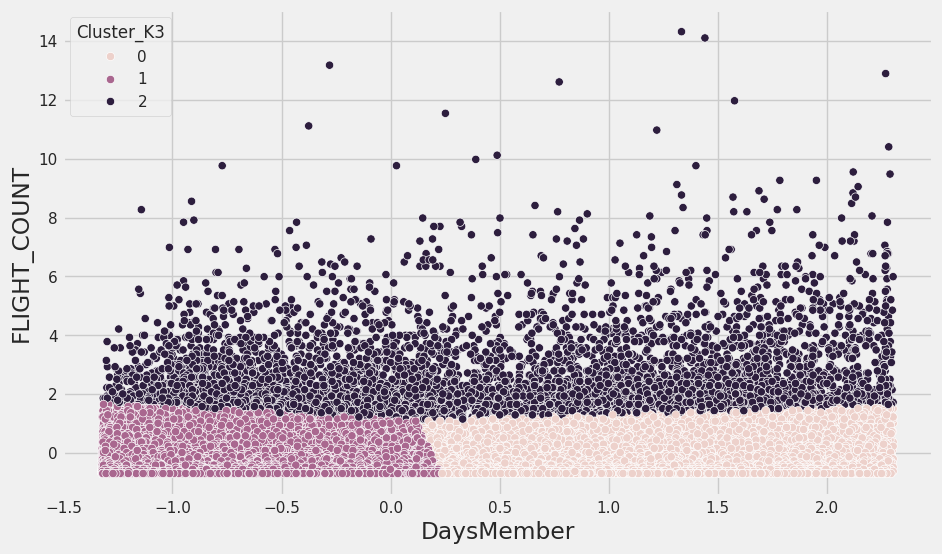

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_km_scaled, x = feature_x, y = feature_y, hue = 'Cluster_K3')
plt.show()

####**Interpretation**

1. Cluster 0 (merah muda)
   - DaysMember tinggi → anggota sudah lama bergabung.
   - Flight_Count rendah → jarang terbang meskipun sudah lama menjadi anggota.
   - Profil: anggota lama yang tidak aktif / dormant.

2. Cluster 1 (ungu muda)
   - DaysMember rendah → anggota baru.
   - Flight_Count rendah → baru bergabung, belum banyak aktivitas.
   - Profil: anggota baru belum teraktivasi.

3. Cluster 2 (ungu tua)
   - Ada di seluruh rentang DaysMember.
   - Flight_Count tinggi → anggota aktif, baik yang lama maupun baru.
   - Profil: anggota aktif / **frequent flyers**, basis pelanggan inti.




####**Insights**

1. Cluster 0 (lama tapi pasif) berpotensi churn: mereka sudah lama terdaftar, tapi tidak loyal dalam penerbangan.
2. Cluster 1 (baru, pasif) perlu didorong supaya cepat menjadi pengguna aktif → kritis untuk konversi awal.
1. Cluster 2 (aktif) adalah segmen paling berharga, menyumbang mayoritas penerbangan.

####**Recommendation**

1. Cluster 0 – Anggota lama tapi pasif
   - Lakukan re-engagement campaign: promo eksklusif, diskon untuk anggota lama, reminder poin kadaluarsa.
   - Analisis apakah mereka pindah ke kompetitor atau hanya berhenti terbang.

2. Cluster 1 – Anggota baru pasif
   - Fokus pada onboarding: promo “first flight”, welcome bonus, edukasi manfaat loyalty program.
   - Dorong keterlibatan sejak awal agar tidak cepat drop out.

3. Cluster 2 – Frequent flyers (aktif)
   - Pertahankan dengan program loyalitas premium: upgrade tier, lounge, prioritas check-in.
   - Jadikan brand advocate: referral bonus untuk membawa anggota baru.
   - Bundling dengan produk partner (hotel, kartu kredit, e-commerce).